## Activation Functions 
Each neuron in a neural network computes the weighted sum of its inputs and passes the resulting scalar to a function called "Activation function" or "Transfer function" which gives the final output from the neuron

Basically Activation functions are mathematical equations that define how weighted sum in a node is transformed into output
$$
O = g(w_1x_1 + w_2x_2 + ... + b)
$$

where O is output and g is activation function

When activation function taken as linear function $g(z) = z$, Then model performs linear regression or basic classification problems only. 

In general g is taken to be non linear function to be used in non linear regression and classification problems that are not linearly solvable

In [1]:
#Proof that NN behaves as linear model when activation function is g(z)=z

from keras import Sequential
from keras.layers import Dense, Input
from mlxtend.plotting import plot_decision_regions

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

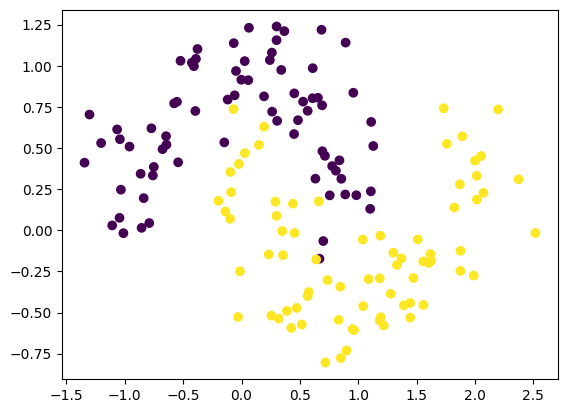

In [8]:
X,y = make_moons(150, noise=0.2)
plt.scatter(X[:,0],X[:,1],c=y)

In [12]:
lin_model = Sequential()

lin_model.add(Input((X.shape[1],)))
lin_model.add(Dense(128, activation='linear'))
lin_model.add(Dense(128, activation='linear'))
lin_model.add(Dense(1, activation='sigmoid'))

lin_model.compile(optimizer= 'Adam', loss= 'binary_crossentropy', metrics=['Accuracy'])
lin_history = lin_model.fit(X,y, epochs=200, batch_size=X.shape[0],verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 662us/step


<Axes: >

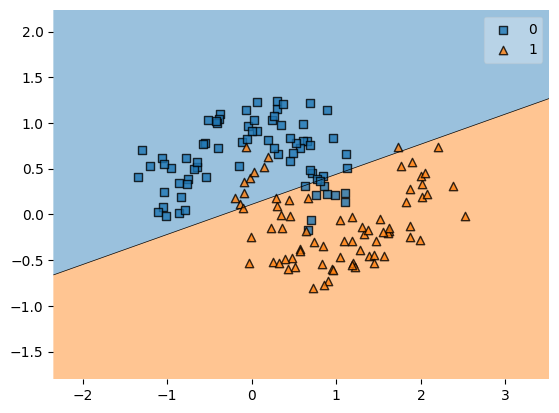

In [14]:
plot_decision_regions(X,y, clf=lin_model)

In [13]:
nlin_model = Sequential()

nlin_model.add(Input((X.shape[1],)))
nlin_model.add(Dense(128, activation='relu'))
nlin_model.add(Dense(128, activation='relu'))
nlin_model.add(Dense(1, activation='sigmoid'))

nlin_model.compile(optimizer= 'Adam', loss= 'binary_crossentropy', metrics=['Accuracy'])
nlin_history = nlin_model.fit(X,y, epochs=200, batch_size=X.shape[0],verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 675us/step


<Axes: >

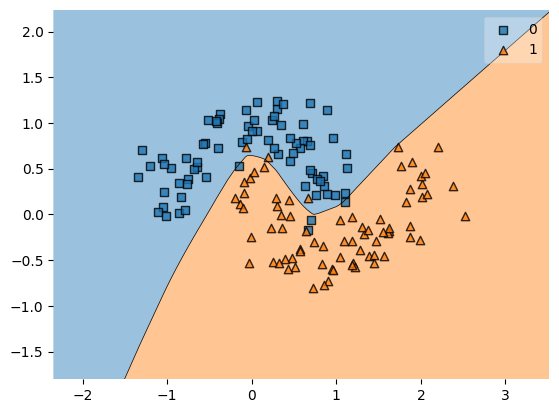

In [15]:
plot_decision_regions(X,y, clf=nlin_model)

___Why does it happen___?   

![WhatsApp Image 2026-02-20 at 3.05.37 PM.jpeg](<attachment:WhatsApp Image 2026-02-20 at 3.05.37 PM.jpeg>)

So, when we use linear activation function in the neural networks that are not able to capture non-linear relationships between input and target
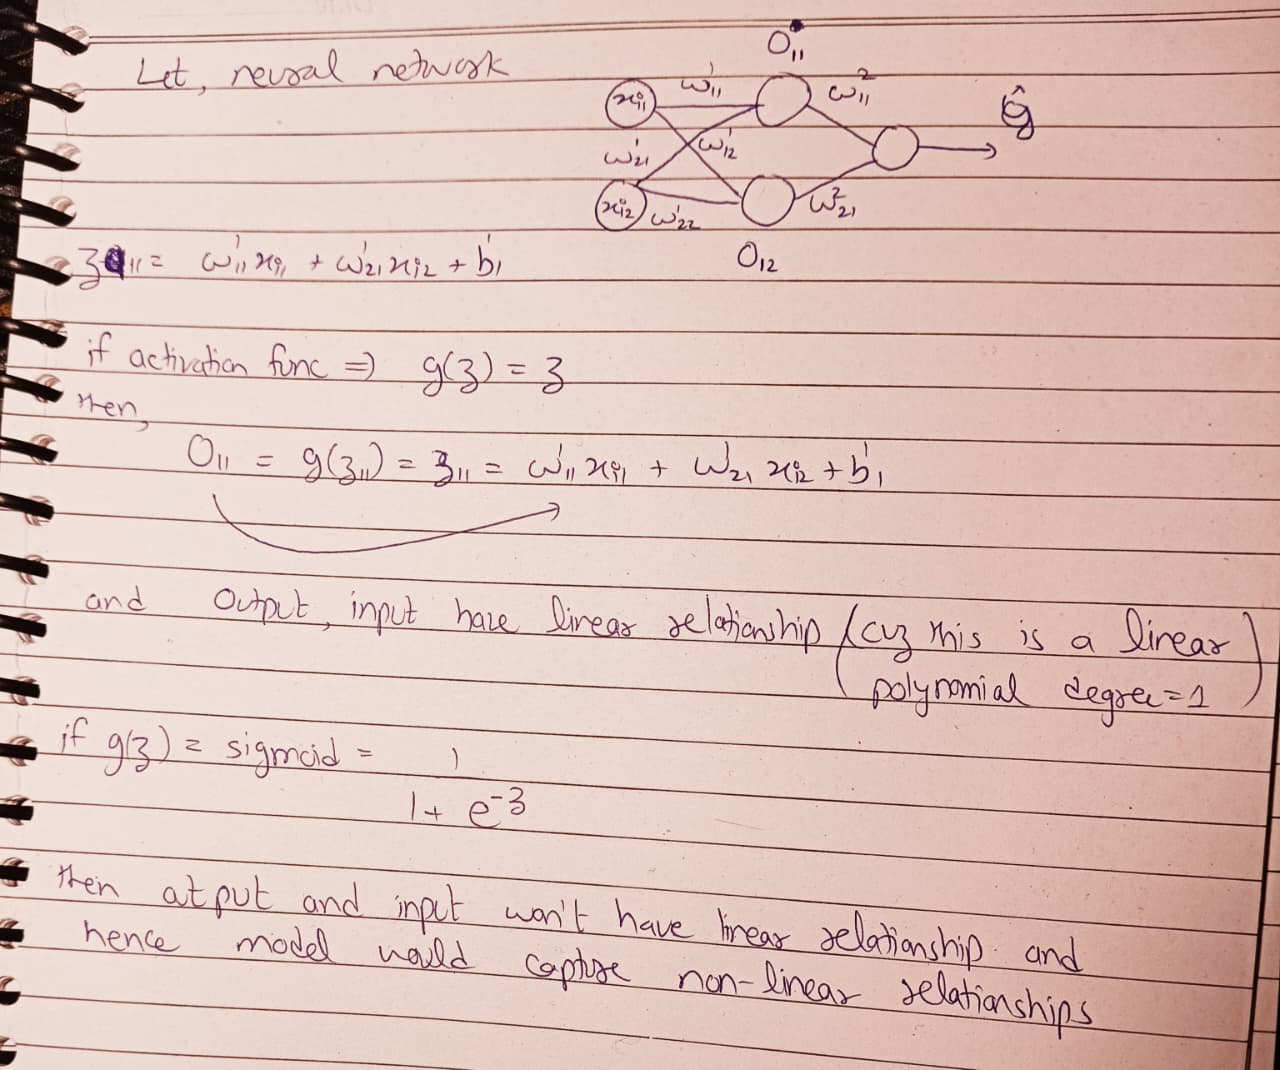

### Ideal Activation function 
- Non linear: To capture non linear patterns in data
- Computationally inexpensive: Function whos derivative is easy to calculate so it takes less training time
- Differentiable: Since we use Gradient descent where we calculate gradients, the activation function should be differentiable
- Zero Centered (Or Normalized): It is observed that training becomes faster if data have mean=0
- Non-Saturating: Non-saturating is a function that does not flatten out (saturate) i.e does not squeez the inputs to a small range. Ex tanh is a saturating function and squeezes the inputs in rage of (-1,1) this causes Vanishing Gradient problem

_why the function should be Zero centered?_  
when $\text{mean} \neq 0$, This happens 

![WhatsApp Image 2026-02-20 at 3.22.08 PM.jpeg](<attachment:WhatsApp Image 2026-02-20 at 3.22.08 PM.jpeg>)
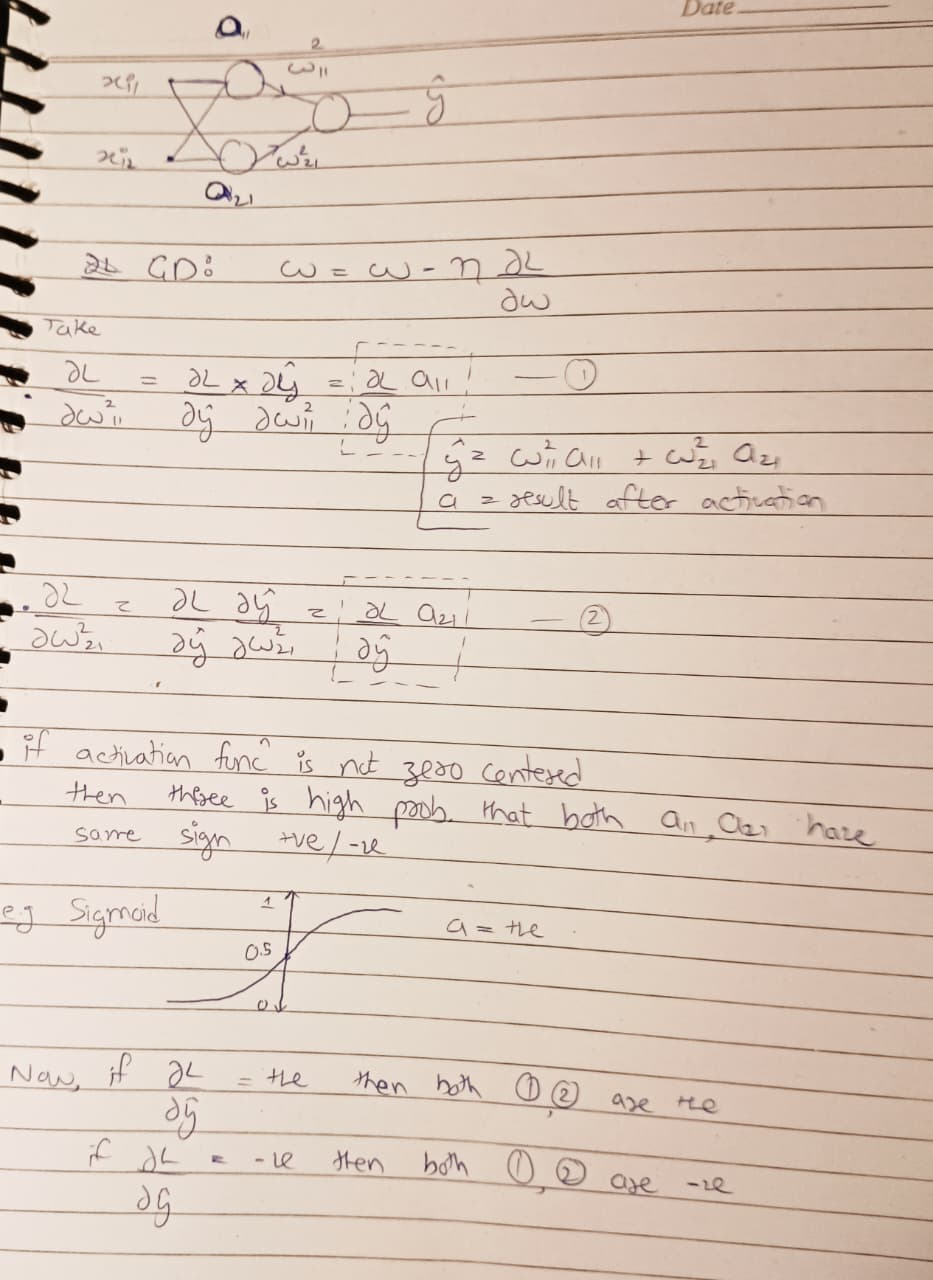

If the function was zero centered then, some gradients would be positive and some would be negative and hence the weights would have more freedom to change values and reach minima

But now there is restriction 

_This makes the training slow_